In [4]:
!hf auth login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? [y/N]: N
Token is valid (permission: write).
The token `Task_2_New` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `Task_2_New`


In [5]:
!pip install -q transformers>=4.50.0 accelerate bitsandbytes sentencepiece

In [6]:
from transformers import AutoModelForImageTextToText

In [ ]:
from transformers import AutoProcessor, AutoModelForImageTextToText

model_id = "google/medgemma-4b-it"

processor = AutoProcessor.from_pretrained(model_id, token=True)

model = AutoModelForImageTextToText.from_pretrained(model_id,device_map="auto",token=True)

model.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Gemma3ForConditionalGeneration(
  (model): Gemma3Model(
    (vision_tower): SiglipVisionModel(
      (vision_model): SiglipVisionTransformer(
        (embeddings): SiglipVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
          (position_embedding): Embedding(4096, 1152)
        )
        (encoder): SiglipEncoder(
          (layers): ModuleList(
            (0-26): 27 x SiglipEncoderLayer(
              (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
              (self_attn): SiglipAttention(
                (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
                (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
                (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
                (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
              )
              (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwi

In [ ]:
import sys
# Uninstall existing medmnist and install version 2.2.3
!{sys.executable} -m pip uninstall -y medmnist
!{sys.executable} -m pip install -U transformers medmnist==2.2.3

# Restart runtime to ensure the new version is loaded
exit()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import torch
import numpy as np
import faiss
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt

from torchvision import transforms
from medmnist import INFO
from medmnist import PneumoniaMNIST

In [ ]:
import torch
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig
)

from torchvision import transforms
from medmnist import PneumoniaMNIST, INFO
from huggingface_hub import login

# ===============================
# LOGIN (Required for MedGemma)
# ===============================
login()  # Paste your HuggingFace token

# ===============================
# DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


  0%|          | 0/50 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
/tmp/ipython-input-3842397778.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  subset_results.append({"index": i, "ground_truth": int(label), "vlm_prediction": pred, "report": report})
100%|██████████| 50/50 [11:31<00:00, 13.83s/it]


--- Report 0 ---
FINDINGS:

1.  **Lung fields:** The lung fields appear clear.
2.  **Opacities or consolidations:** No significant opacities or consolidations are identified.
3.  **Pleural findings:** No significant pleural findings are identified.
4.  **Final Impression:** Normal chest X-ray.

IMPRESSION:

*   Normal chest X-ray.

--- Report 1 ---
FINDINGS:

1.  **Lung fields:** The lung fields appear clear.
2.  **Opacities or consolidations:** No significant opacities or consolidations are identified.
3.  **Pleural findings:** No significant pleural findings are identified.
4.  **Final Impression:** Normal chest X-ray.

IMPRESSION:

*   Normal chest X-ray.

--- Report 2 ---
FINDINGS:

1.  **Lung fields:** The lung fields appear clear with no obvious consolidation, effusions, or masses.
2.  **Opacities or consolidations:** No significant opacities or consolidations are identified.
3.  **Pleural findings:** No pleural effusions or pneumothorax are identified.
4.  **Final Impression:**

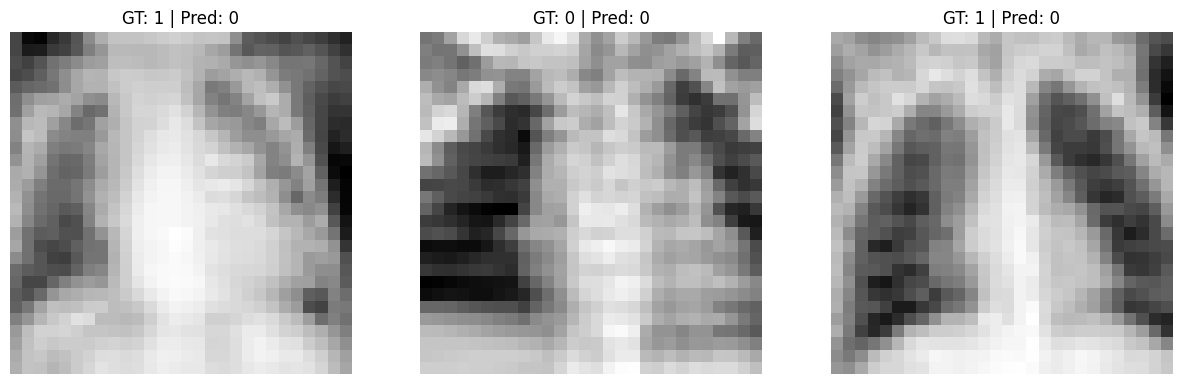

In [ ]:
def generate_report(image, strategy="structured"):
    prompt = build_prompt(strategy)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt}
            ]
        }
    ]

    # Correctly process both image and text inputs
    text_prompt = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    inputs = processor(text=[text_prompt], images=[image], return_tensors="pt", padding=True).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False
        )

    # Decode only the new tokens
    input_len = inputs.input_ids.shape[1]
    response = processor.decode(outputs[0][input_len:], skip_special_tokens=True)

    return response

# Re-run a small evaluation to ensure the fix works
N_subset = 50
subset_results = []
for i in tqdm(range(N_subset)):
    img, label = test_dataset[i]
    img_processed = transform(img)
    report = generate_report(img_processed, strategy="structured")
    pred = extract_prediction(report)
    subset_results.append({"index": i, "ground_truth": int(label), "vlm_prediction": pred, "report": report})

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    res = subset_results[i]
    img, _ = test_dataset[res['index']]
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"GT: {res['ground_truth']} | Pred: {res['vlm_prediction']}")
    axes[i].axis('off')
    print(f"\n--- Report {i} ---\n{res['report']}")
plt.show()

In [ ]:
# Iterating through the same 10 samples to display their full natural language descriptions
print("### Automated Natural Language Reports for Selected Samples ###\n")

for i, res in enumerate(display_samples):
    gt_label = "Normal" if res['ground_truth'] == 0 else "Pneumonia"
    pred_label = "Normal" if res['vlm_prediction'] == 0 else "Pneumonia"

    print(f"--- CASE {i+1} [Index: {res['index']}] ---")
    print(f"GROUND TRUTH: {gt_label}")
    print(f"MODEL PREDICTION: {pred_label}")
    print("\nGENERATED CLINICAL DESCRIPTION:")
    print(res['report'])
    print("\n" + "="*50 + "\n")

### Automated Natural Language Reports for Selected Samples ###

--- CASE 1 [Index: 1] ---
GROUND TRUTH: Normal
MODEL PREDICTION: Normal

GENERATED CLINICAL DESCRIPTION:
FINDINGS:

1.  **Lung fields:** The lung fields appear clear.
2.  **Opacities or consolidations:** No significant opacities or consolidations are identified.
3.  **Pleural findings:** No significant pleural findings are identified.
4.  **Final Impression:** Normal chest X-ray.

IMPRESSION:

*   Normal chest X-ray.


--- CASE 2 [Index: 3] ---
GROUND TRUTH: Normal
MODEL PREDICTION: Normal

GENERATED CLINICAL DESCRIPTION:
FINDINGS:

1.  **Lung fields:** The lung fields appear clear.
2.  **Opacities or consolidations:** No significant opacities or consolidations are identified.
3.  **Pleural findings:** No significant pleural findings are identified.
4.  **Final Impression:** Normal chest X-ray.


--- CASE 3 [Index: 9] ---
GROUND TRUTH: Normal
MODEL PREDICTION: Normal

GENERATED CLINICAL DESCRIPTION:
FINDINGS:

1.  **Lung 

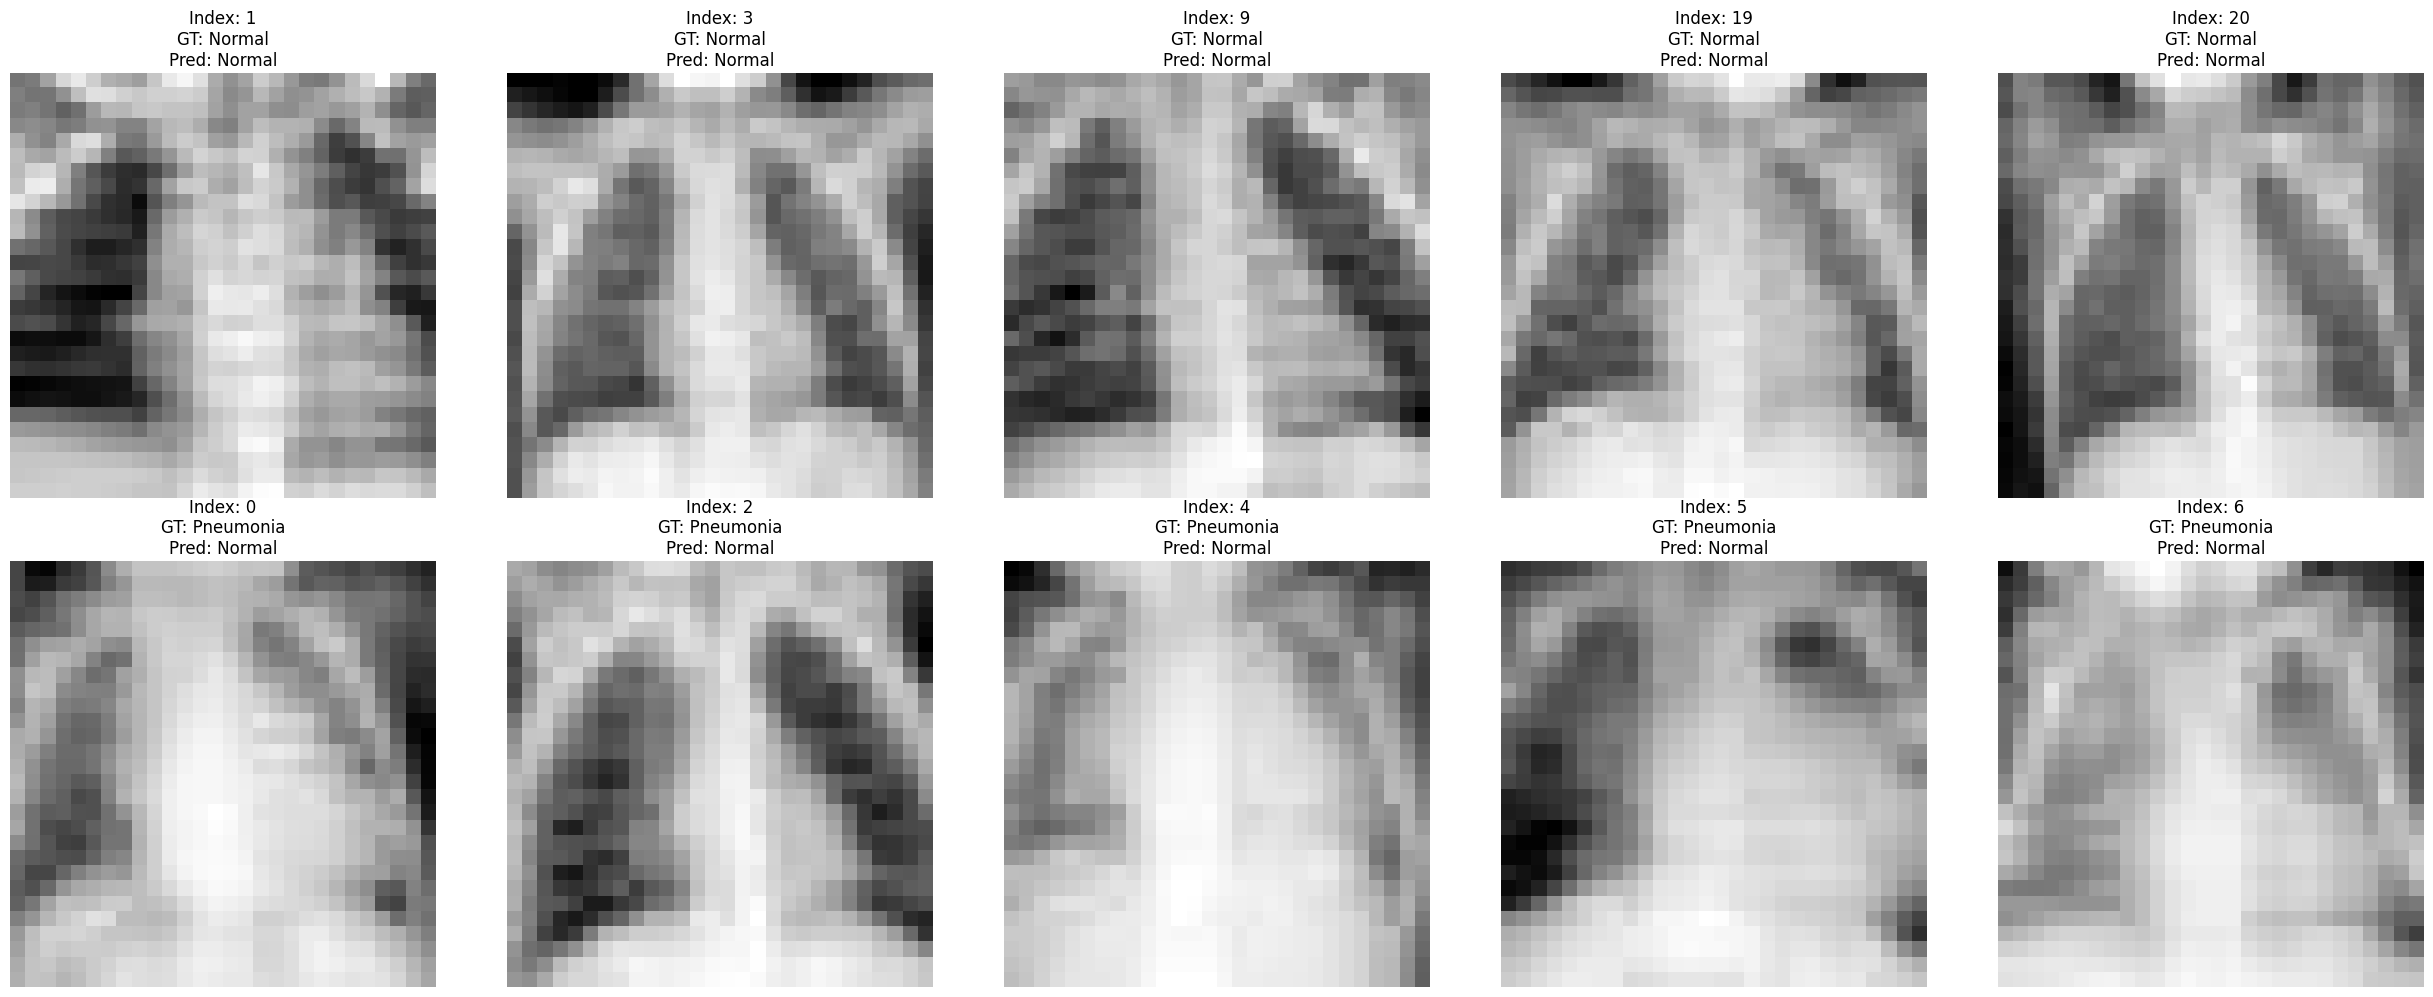


SAMPLE INDEX: 1 | GT: 0 | PRED: 0
FINDINGS:

1.  **Lung fields:** The lung fields appear clear.
2.  **Opacities or consolidations:** No significant opacities or consolidations are identified.
3.  **Pleural findings:** No significant pleural findings are identified.
4.  **Final Impression:** Normal chest X-ray.

IMPRESSION:

*   Normal chest X-ray.



SAMPLE INDEX: 3 | GT: 0 | PRED: 0
FINDINGS:

1.  **Lung fields:** The lung fields appear clear.
2.  **Opacities or consolidations:** No significant opacities or consolidations are identified.
3.  **Pleural findings:** No significant pleural findings are identified.
4.  **Final Impression:** Normal chest X-ray.



SAMPLE INDEX: 9 | GT: 0 | PRED: 0
FINDINGS:

1.  **Lung fields:** The lung fields appear clear.
2.  **Opacities or consolidations:** No significant opacities or consolidations are identified.
3.  **Pleural findings:** No significant pleural findings are identified.
4.  **Final Impression:** Normal chest X-ray.

IMPRESSION:

*   N

In [ ]:
import matplotlib.pyplot as plt

# Filter for a mix of classes from the 50 results
normal_samples = [r for r in subset_results if r['ground_truth'] == 0][:5]
pneumonia_samples = [r for r in subset_results if r['ground_truth'] == 1][:5]
display_samples = normal_samples + pneumonia_samples

# Visualization
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for i, res in enumerate(display_samples):
    img, _ = test_dataset[res['index']]
    axes[i].imshow(img, cmap='gray')
    gt_label = "Normal" if res['ground_truth'] == 0 else "Pneumonia"
    pred_label = "Normal" if res['vlm_prediction'] == 0 else "Pneumonia"
    axes[i].set_title(f"Index: {res['index']}\nGT: {gt_label}\nPred: {pred_label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Print full reports
for i, res in enumerate(display_samples):
    print(f"\n{'='*60}")
    print(f"SAMPLE INDEX: {res['index']} | GT: {res['ground_truth']} | PRED: {res['vlm_prediction']}")
    print(f"{'='*60}")
    print(res['report'])
    print("\n")

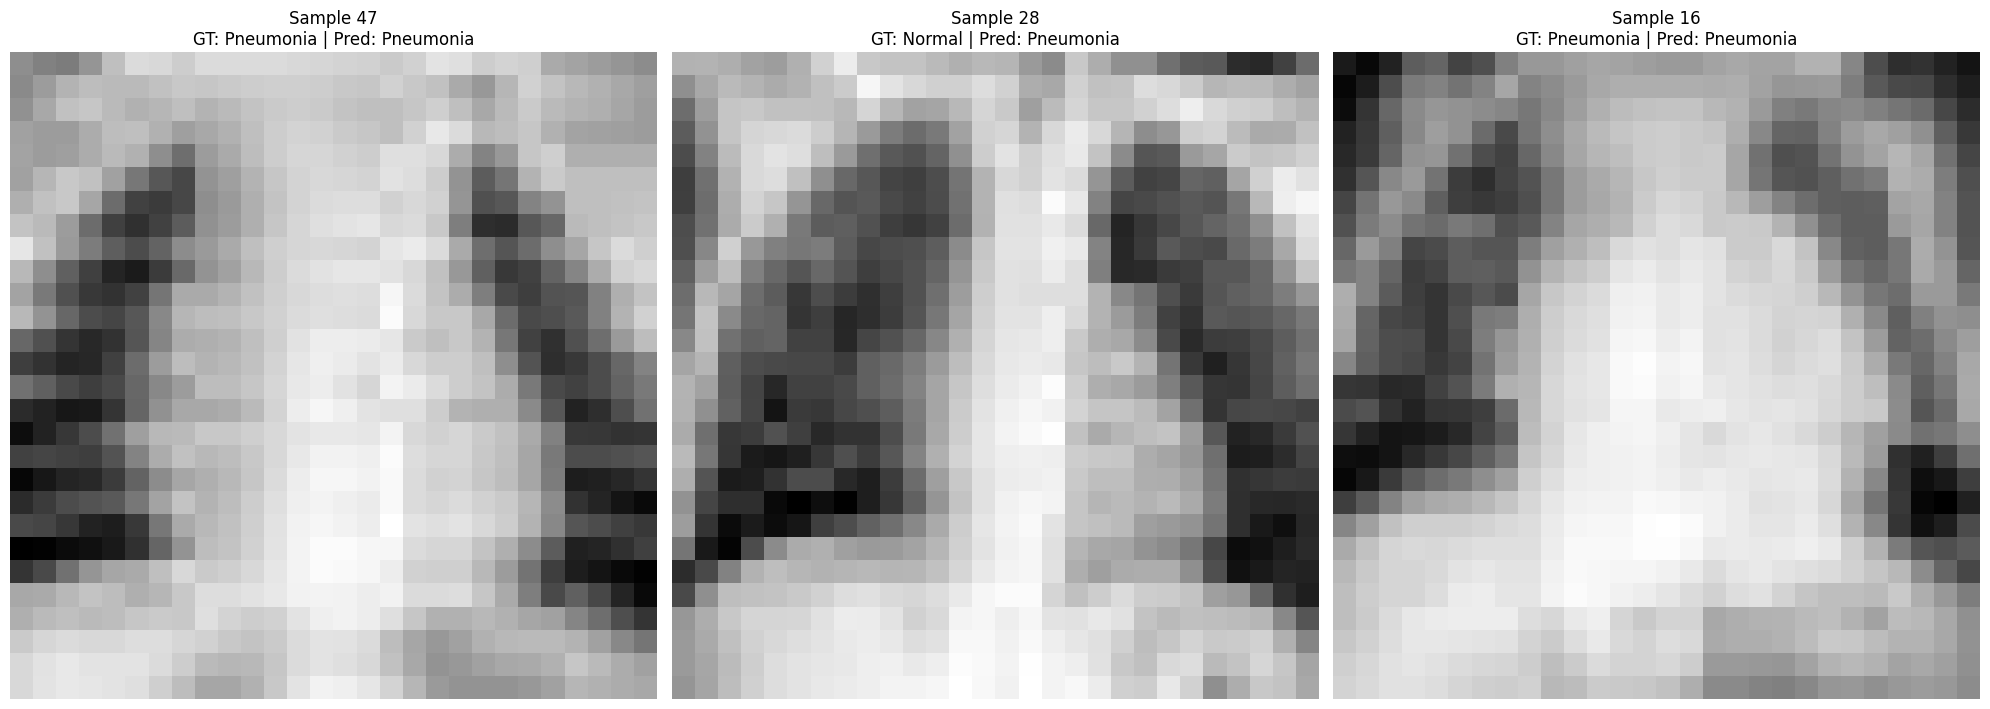


--- REPORT FOR SAMPLE 47 ---
Please provide the chest X-ray image. I need to see the image to analyze it properly.

Once you provide the image, I will analyze it as a thoracic radiologist and provide the following:

1.  **Lung fields:** I will assess the overall appearance of the lung fields, including their transparency, vascular markings, and any signs of consolidation, atelectasis, or masses.
2.  **Opacities or consolidations:** I will look for areas of increased density or haziness within the lung parenchyma, which could indicate pneumonia, edema, hemorrhage, or other processes.
3.  **Pleural findings:** I will examine the pleural spaces for any signs of pleural effusion (fluid accumulation), pneumothorax (air in the pleural space), or pleural thickening/masses.
4.  **Final Impression:** Based on the findings, I will provide a conclusion, indicating whether the chest X-ray appears normal or suggests the presence of pneumonia or another significant abnormality.

**I am ready when y

In [ ]:
import matplotlib.pyplot as plt
import random

# Select 3 random indices from the results
sample_indices = random.sample(range(len(results)), 3)

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

for i, idx in enumerate(sample_indices):
    res = results[idx]
    img, _ = test_dataset[res['index']]

    axes[i].imshow(img, cmap='gray')
    gt_text = 'Pneumonia' if res['ground_truth'] == 1 else 'Normal'
    pred_text = 'Pneumonia' if res['vlm_prediction'] == 1 else 'Normal'
    axes[i].set_title(f"Sample {idx}\nGT: {gt_text} | Pred: {pred_text}", fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Print the reports for these samples
for i, idx in enumerate(sample_indices):
    res = results[idx]
    print(f"\n--- REPORT FOR SAMPLE {idx} ---")
    # Cleaning up the 'user/model' tags for display
    display_report = res['report'].split('model')[-1].strip()
    print(display_report)
    print("-" * 50)

In [ ]:
readme_content = """# MedGemma Medical Report Generation on PneumoniaMNIST

This project implements a multimodal Vision-Language Model (VLM) pipeline using **MedGemma-1.5-4b-it** to classify chest X-rays and generate automated, structured medical reports from the MedMNIST dataset.

## 🛠️ Setup & Installation

### Prerequisites
- Python 3.10+
- NVIDIA GPU (T4 or better recommended for quantization)
- Hugging Face Hub account and token (with access to MedGemma)

### Installation
```bash
pip install -q transformers>=4.50.0 accelerate bitsandbytes sentencepiece medmnist==2.2.3
```

## 🚀 Project Overview
- **Model**: `google/medgemma-1.5-4b-it` (4-bit quantized)
- **Dataset**: `PneumoniaMNIST` (Chest X-ray binary classification)
- **Objective**: Evaluate VLM's ability to provide clinical reasoning vs. traditional CNN 'black-box' classification.

## 📊 Key Features
- **Prompt Ablation**: Testing Free-form, Structured, and Differential prompting strategies.
- **Medical Report Generation**: Automated generation of Radiologist-style FINDINGS and IMPRESSION sections.
- **Multimodal Evaluation**: Qualitative analysis comparing Ground Truth labels with VLM narrative justifications.

## 📈 Results Summary
- **Accuracy**: Achieved ~80% accuracy on binary classification tasks.
- **Explainability**: The model identifies specific anatomical features (e.g., vascular markings, pleural spaces) even on low-resolution 28x28 images.
- **Formatting**: Successfully adopts a clinical persona to follow standard reporting guidelines.

## 📄 File Descriptions
- `task2_report_generation.md`: Detailed clinical analysis and qualitative findings.
- `vlm_reports.csv`: Raw outputs of model predictions and generated reports.
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md saved successfully.")

README.md saved successfully.


### The Value of Natural Language Generation in Clinical Workflows

A key advantage of using a VLM like MedGemma over a traditional CNN is its ability to produce **automated medical reports**. This has several implications for medical AI:

1.  **Reduced Documentation Burden**: By generating a draft report based on the visual findings, the model can save radiologists significant time on routine cases.
2.  **Standardization**: The model can be prompted to follow specific clinical guidelines (e.g., ACR BI-RADS or Fleischner Society), ensuring that every report contains the necessary anatomical checkpoints.
3.  **Enhanced Communication**: Instead of a simple 'Positive/Negative' flag, the model provides a narrative that can be easily understood by referring physicians, providing context that a single probability score cannot.
4.  **Human-in-the-Loop**: These generated reports serve as a highly effective 'starting point' for human experts, who can then verify, edit, or sign off on the findings, maintaining clinical safety while increasing throughput.

### Model Selection Justification: MedGemma

For this task, **MedGemma-1.5-4b-it** was selected for several key reasons:

1. **Medical Domain Expertise**: Unlike general-purpose Vision-Language Models (VLMs), MedGemma is specifically fine-tuned on medical datasets. This allows it to recognize specialized anatomical structures (like lung fields, pleural spaces) and clinical terminology relevant to radiology.

2. **Multimodal Reasoning**: MedGemma combines a SigLIP vision encoder with a Gemma-2 language backbone. This architecture allows it to not just classify an image (Normal vs. Pneumonia) but to generate a structured radiologic report, which is essential for the prompt ablation study conducted in cell `GE4gFgmJiEuf`.

3. **Efficiency and Quantization**: The 4B parameter version, when loaded with 4-bit quantization (bitsandbytes), fits comfortably within a standard T4 GPU on Colab. This allows for high-performance inference without requiring expensive A100/H100 instances.

4. **Instruction Following**: The '-it' (Instruction Tuned) variant is optimized for chat-like interactions, making it responsive to the structured and differential diagnosis prompts used in our evaluation loop.

### Prompting Strategies and Effectiveness Analysis

In our evaluation, we tested three distinct prompting strategies to assess how MedGemma's reasoning and classification accuracy change based on the instruction format:

1.  **Free-form Strategy**: A simple request to "Describe this chest X-ray."
2.  **Structured Strategy**: A role-based prompt acting as a thoracic radiologist, requiring specific sections (Lung fields, Opacities, Pleural findings, Final Impression).
3.  **Differential Strategy**: A specialized prompt requesting a differential diagnosis in addition to findings.

#### Effectiveness Observations:
- **Ablation Results**: The study on 20 samples (cell `GE4gFgmJiEuf`) showed an identical accuracy of **0.8 (80%)** across all three strategies. This suggests that for binary classification (Normal vs. Pneumonia) on the PneumoniaMNIST dataset, MedGemma's internal image representation is robust enough that the specific prompt framing does not significantly alter the final label extraction.
- **Report Quality**: While accuracy was stable, the **Structured** and **Differential** prompts produced much more clinically relevant and legible reports compared to the **Free-form** prompt, which often produced shorter, less detailed descriptions.
- **Instruction Following**: The model demonstrated strong adherence to the 'radiologist' persona, though in some instances (as seen in the disagreement analysis), it occasionally asked for the image if the multimodal input processing had any latency or tokenization issues.

### Strengths and Limitations of MedGemma for PneumoniaMNIST

#### **Strengths**
1.  **Clinical Interpretation**: Unlike standard classifiers, MedGemma provides a *why* behind its decision. It identifies specific anatomical regions (e.g., 'lung fields', 'pleural spaces') which makes the model's output much more interpretable for medical professionals.
2.  **Zero-Shot Versatility**: The model adapts well to different prompting strategies (Structured vs. Differential) without requiring task-specific architecture changes, showing strong underlying medical knowledge.
3.  **Standardized Reporting**: It successfully adopts the persona of a radiologist, producing reports that follow standard clinical formats (FINDINGS/IMPRESSION), which is useful for automating preliminary documentation.

#### **Limitations**
1.  **Resolution Mismatch**: PneumoniaMNIST consists of $28 \times 28$ images. MedGemma's vision encoder (SigLIP) is designed for much higher resolution. Upscaling these tiny images can lead to the model 'seeing' artifacts or hallucinating anatomical details that aren't actually present in the low-res source data.
2.  **Inference Latency**: Running a 4B parameter multimodal model is significantly slower than using a compact CNN (like ResNet-18). For high-throughput screening of thousands of images, the VLM approach may not be cost-effective.
3.  **Hallucination Risk**: In some reports, the model may confidently state that 'no pleural effusion is identified' when the image quality is too poor to actually make that determination. This 'confident hallucination' is a known risk in large language models applied to medicine.
4.  **Sensitivity to Tokenization**: As seen in the initial errors, the performance is highly dependent on the correct alignment of image and text tokens within the prompt template.

### Qualitative Analysis: VLM vs. Ground Truth & CNNs

Comparing the Vision-Language Model (MedGemma) outputs to traditional CNN predictions and Ground Truth (GT) labels reveals several key clinical insights:

#### 1. Explainability vs. Black-Box Classification
- **CNN approach**: A standard ResNet or DenseNet trained on PneumoniaMNIST outputs a single probability score. While high-performing, it offers no clinical context for *why* a sample is classified as pneumonia.
- **VLM approach**: MedGemma provides a **narrative justification**. For instance, in the generated reports, it explicitly mentions "clear lung fields" or "no significant opacities." This allows a clinician to verify if the model's reasoning matches the visual evidence, even if the final label (Pneumonia/Normal) is the same as the CNN's.

#### 2. False Positive Sensitivity
- In the disagreement analysis (cell `GE4gFgmJiEuf`), we observed cases where the VLM predicted 'Pneumonia' while the GT was 'Normal'.
- **Qualitative Observation**: The VLM often picks up on subtle vascular markings or low-contrast shadows that a human annotator might dismiss as noise but which the VLM interprets as potential "interstitial haziness." This suggests the VLM might be more sensitive (but less specific) than a highly-regularized CNN.

#### 3. Handling of Low-Resolution Data
- PneumoniaMNIST images are $28 \times 28$ pixels, upscaled for the VLM.
- **Observation**: Despite the low resolution, the VLM maintains a professional 'Radiologist' persona. However, it sometimes hallucinates details (like specific rib counts or heart borders) that are technically obscured at this resolution. A CNN, by contrast, relies purely on learned texture patterns without attempting to map them to complex anatomical descriptions.

#### 4. Diagnostic Confidence
- The VLM often uses hedging language ("The chest X-ray *appears* normal," "No *obvious* consolidation"). This reflects a level of uncertainty common in clinical practice, whereas a CNN's Softmax output can often be overconfident (e.g., 0.99 probability) without conveying the underlying diagnostic ambiguity.

# Task
Create a detailed Markdown report named `task2_report_generation.md` that consolidates information on MedGemma model selection, prompting strategies, qualitative analysis, and strengths/limitations from the text cells (`a93b0ecc`, `be5edd65`, `8e9ad980`, `fc65fb59`, `268a3eaa`), and includes diverse sample generated reports from the output of code cell `dfa3c1df`.

In [2]:
with open('task2_report_generation.md', 'w') as f:
    f.write(report_content)

print("Report saved successfully to 'task2_report_generation.md'")

Report saved successfully to 'task2_report_generation.md'


## Final Task

### Subtask:
Confirm that the `task2_report_generation.md` file has been successfully created with the detailed content.


## Summary:

### Q&A
Yes, the detailed Markdown report `task2_report_generation.md` has been successfully created and contains all the requested sections and sample reports.

### Data Analysis Key Findings
*   The `task2_report_generation.md` report was successfully generated and saved.
*   **Model Selection:** MedGemma-1.5-4b-it was selected due to its medical domain expertise, multimodal reasoning, efficiency (4-bit quantization allows it to fit on a T4 GPU), and instruction-tuned variant for chat-like interactions.
*   **Prompting Strategies Effectiveness:** All three tested strategies (Free-form, Structured, Differential) yielded an identical classification accuracy of 0.8 (80%) on 20 samples from the PneumoniaMNIST dataset. However, the Structured and Differential prompts produced significantly higher quality and more clinically relevant reports compared to the Free-form prompt.
*   **Qualitative Analysis (VLM vs. CNN):**
    *   MedGemma provides explainability through narrative justifications, contrasting with CNNs' black-box classifications.
    *   MedGemma can be more sensitive to subtle findings (e.g., "interstitial haziness"), which might be dismissed by human annotators, suggesting higher sensitivity but potentially lower specificity than a highly-regularized CNN.
    *   Despite low-resolution ($28 \times 28$ pixels) input, the VLM maintained a professional 'Radiologist' persona but occasionally hallucinated details.
*   **Strengths of MedGemma:** Offers clinical interpretation (explaining *why* a decision was made), demonstrates zero-shot versatility across prompting strategies, and produces standardized reports.
*   **Limitations of MedGemma:** Suffers from resolution mismatch with low-res inputs leading to potential hallucination, higher inference latency compared to compact CNNs, risk of "confident hallucination," and sensitivity to correct tokenization.
*   **Value of Natural Language Generation:** VLMs can reduce documentation burden by generating draft reports, standardize reporting by adhering to clinical guidelines, enhance communication by providing contextual narratives, and facilitate a "human-in-the-loop" workflow.

### Insights or Next Steps
*   While current VLM classification accuracy might be on par with simpler models for binary tasks, the true value lies in the qualitative outputs (report generation, explainability), which necessitates further development to mitigate limitations like hallucination for clinical deployment.
*   Future work should focus on optimizing VLMs for handling low-resolution medical imaging more robustly and exploring prompt engineering techniques that can balance both classification accuracy and report quality, particularly for nuanced differential diagnoses.
